## Dataset Overview

This dataset is used for predicting the bankruptcy of Polish companies based on financial indicators and ratios. Bankrupt companies were analyzed during the period **2000–2012**, while companies that remained operational were evaluated from **2007–2013**.

The dataset contains multiple forecasting scenarios and a collection of financial features that can be used to build and evaluate bankruptcy prediction models.

For additional details about the dataset structure, forecasting periods, feature definitions, and target variable, refer to the **`dataset_description.md`** and **`data_dictionary.md`** files located in the **`references/`** directory.


In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("../data/raw/Bankruptcy Master Dataset.csv",low_memory=False, index_col="id", dtype="float", na_values="?")
df[["Class","Year"]]=df[["Class","Year"]].astype("int")
df.index=df.index.astype("int")
df = df.reset_index(drop=True)
df.head()

,Year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,Class
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


In [4]:
# Checking the distribution of tyhe positive and negative classes
df["Class"].value_counts(normalize=True)

Class
0    0.951826
1    0.048174
Name: proportion, dtype: float64

### keep in mind the the feature `class` is our target variable

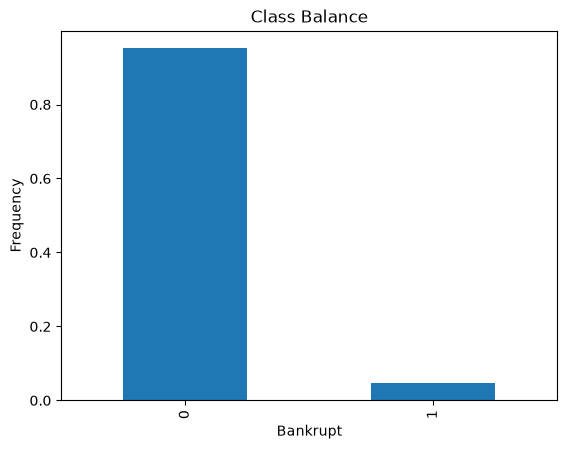

In [5]:
df["Class"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel="Bankrupt",
    ylabel="Frequency",
    title="Class Balance"
);
plt.savefig("../reports/figures/class_balance.png", dpi=150)

## Class `Target Variable` Distribution Analysis

From the visualization above, we can observe that the dataset has a significant imbalance between the positive and negative classes. The number of non-bankrupt companies is much higher than the number of bankrupt companies.

This class imbalance is an important factor to consider when evaluating the performance of classification models. Using **accuracy** alone may not provide a reliable measure, as a model could achieve a high accuracy by simply predicting the majority class while failing to identify bankrupt companies.

Therefore, evaluation metrics that focus on the performance of each class are more suitable for this problem. Metrics such as **precision**, **recall**, **F1-score**, and the **ROC-AUC score** will provide a better understanding of the model's ability to correctly identify bankrupt companies while minimizing false predictions.


## Feature Analysis

Feature **X27 (Profit on operating activities / Financial expenses)** measures the company's ability to cover financial expenses using operating profits. This feature may indicate financial stability, where higher values could suggest lower bankruptcy risk.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 66 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    43405 non-null  int64  
 1   X1      43397 non-null  float64
 2   X2      43397 non-null  float64
 3   X3      43397 non-null  float64
 4   X4      43271 non-null  float64
 5   X5      43316 non-null  float64
 6   X6      43397 non-null  float64
 7   X7      43397 non-null  float64
 8   X8      43311 non-null  float64
 9   X9      43396 non-null  float64
 10  X10     43397 non-null  float64
 11  X11     43361 non-null  float64
 12  X12     43271 non-null  float64
 13  X13     43278 non-null  float64
 14  X14     43397 non-null  float64
 15  X15     43369 non-null  float64
 16  X16     43310 non-null  float64
 17  X17     43311 non-null  float64
 18  X18     43397 non-null  float64
 19  X19     43277 non-null  float64
 20  X20     43278 non-null  float64
 21  X21     37551 non-null  float64
 22  X22     4

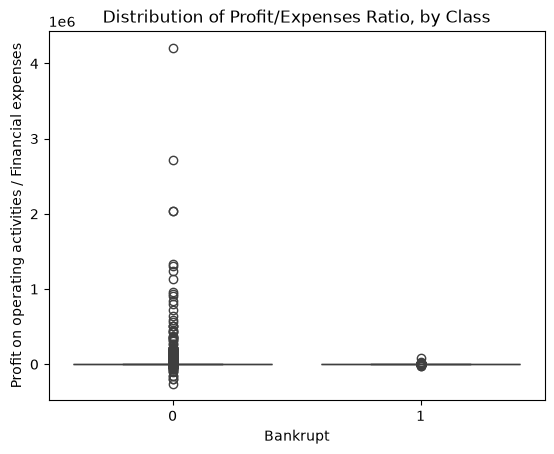

In [7]:
sns.boxplot(x="Class", y="X27",data=df);
plt.xlabel("Bankrupt")
plt.ylabel("Profit on operating activities / Financial expenses")
plt.title("Distribution of Profit/Expenses Ratio, by Class");

In [8]:
df["X27"].describe().apply("{0:,.0f}".format)

count       40,641
mean         1,108
std         35,015
min       -259,000
25%              0
50%              1
75%              5
max      4,210,000
Name: X27, dtype: str

Upon closer examination of the statistical summary, we observe that the median is 1, while the mean is 1108. This substantial difference between the mean and median strongly suggests that the dataset is highly right-skewed. Such skewness indicates the presence of extreme values or outliers that are pulling the mean upward. Addressing this skewness is important, as it may affect the performance and assumptions of certain statistical analyses and machine learning models.


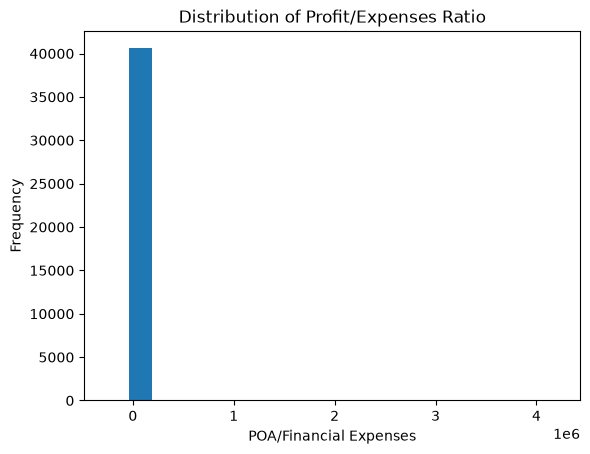

In [9]:
plt.hist(df["X27"], bins=20)
plt.xlabel("POA/Financial Expenses")
plt.ylabel("Frequency")
plt.title("Distribution of Profit/Expenses Ratio");

In [10]:
# POA/Financial expenses outliers
low,high = df["X27"].quantile([0.1,0.9])
df = df[df["X27"].between(low,high)]
df = df.reset_index(drop=True)
df.head()

,Year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,Class
0,1,0.200550,0.379510,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.13890,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.6580,4.4158,7.4277,0
1,1,0.081483,0.307340,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.05710,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.4350,4.2228,5.5497,0
2,1,0.187320,0.613230,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.15590,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.2100,2.8692,7.8980,0
3,1,0.111090,0.647440,0.28971,1.4705,2.5349,0.00000,0.111090,0.54454,1.73480,...,0.605900,0.31510,0.40871,0.000000,6.3222,2.9098,129.5500,2.8173,18.3520,0
4,1,0.532320,0.027059,0.70554,53.9540,299.5800,0.00000,0.652400,35.95700,0.65273,...,0.086730,0.54713,0.49521,0.013194,9.1300,82.0500,7.4503,48.9910,2.3217,0


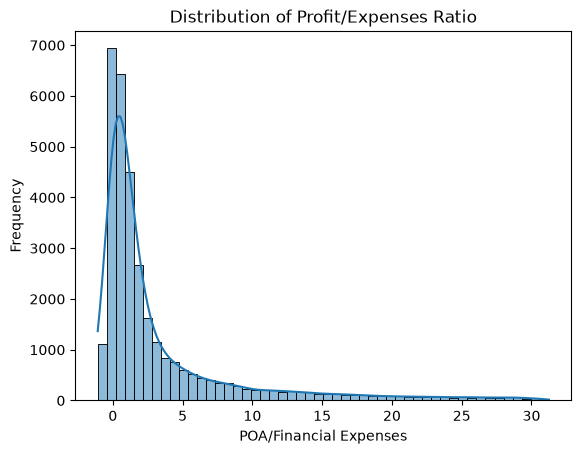

In [11]:
sns.histplot(data = df, x="X27", kde=True, bins=50)
plt.xlabel("POA/Financial Expenses")
plt.ylabel("Frequency")
plt.title("Distribution of Profit/Expenses Ratio");
plt.savefig("../reports/figures/POA_vs_fin_expenses.png", dpi=150)

# Splitting the data

In [12]:
# vertical split
X = df.drop(columns="Class")
y= df["Class"]


In [13]:
# Horizontal split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, shuffle=True)

To address the class imbalance in the target variable, we apply **Random Oversampling**, a widely used resampling technique that increases the number of instances in the minority class by randomly duplicating existing samples. Oversampling is one of the most effective preprocessing methods for handling imbalanced datasets, as it helps create a more balanced class distribution and can improve the performance of machine learning models on underrepresented classes.


In [14]:
from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)



In [15]:
y_train.value_counts()

Class
0    25385
1      625
Name: count, dtype: int64

In [16]:
X_train.shape

(26010, 65)

In [17]:
X_train_over.shape

(50770, 65)

In [18]:
y_train.value_counts(), y_train_over.value_counts()

(Class
 0    25385
 1      625
 Name: count, dtype: int64,
 Class
 0    25385
 1    25385
 Name: count, dtype: int64)

# Baseline

In [19]:
acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline accuracy is: {round(acc_baseline,2)}")

Baseline accuracy is: 0.98


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

# fit the model on X_train, y_train
dtc_model = make_pipeline(SimpleImputer(strategy="median"), DecisionTreeClassifier(random_state=42))
dtc_model.fit(X_train, y_train)

# fit the model on X_trai_over, y_train_over
dtc_model_over = make_pipeline(SimpleImputer(strategy="median"), DecisionTreeClassifier(random_state=42))
dtc_model_over.fit(X_train_over, y_train_over)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](65,)","['Year','X1','X2',...,'X62','X63','X64']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,65
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`

In [21]:
for m in [dtc_model, dtc_model_over]:
    acc_train = m.score(X_train, y_train)
    acc_test = m.score(X_test, y_test)

    print(f"Training accuracy: {round(acc_train,4)}")
    print(f"Test accuracy: {round(acc_test,4)}")

Training accuracy: 1.0
Test accuracy: 0.9656
Training accuracy: 1.0
Test accuracy: 0.9669


### Effect of Oversampling on Model Performance

It is clear from the results that the model trained on the oversampled dataset achieves a higher test accuracy than the model trained on the original imbalanced dataset. This indicates that oversampling helped address the class imbalance, allowing the model to learn more representative decision boundaries for the minority class and improving its overall generalization performance on the test set.

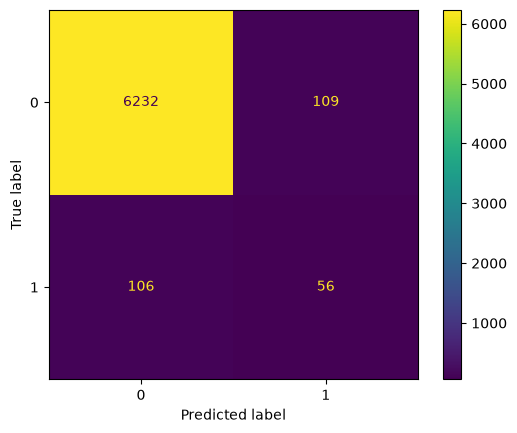

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

# plot Confusion matrix
ConfusionMatrixDisplay.from_estimator(dtc_model_over, X_test, y_test)

In [23]:
# classification report
print(classification_report(y_test, dtc_model_over.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6341
           1       0.34      0.35      0.34       162

    accuracy                           0.97      6503
   macro avg       0.66      0.66      0.66      6503
weighted avg       0.97      0.97      0.97      6503



In [24]:
# confusion matrix
cm = confusion_matrix(y_test ,dtc_model_over.predict(X_test))
print(cm)

[[6232  109]
 [ 106   56]]


In [25]:
# exctracting the decision tree model depth
depth = dtc_model_over.named_steps["decisiontreeclassifier"].get_depth()
depth

47

# Communicating results

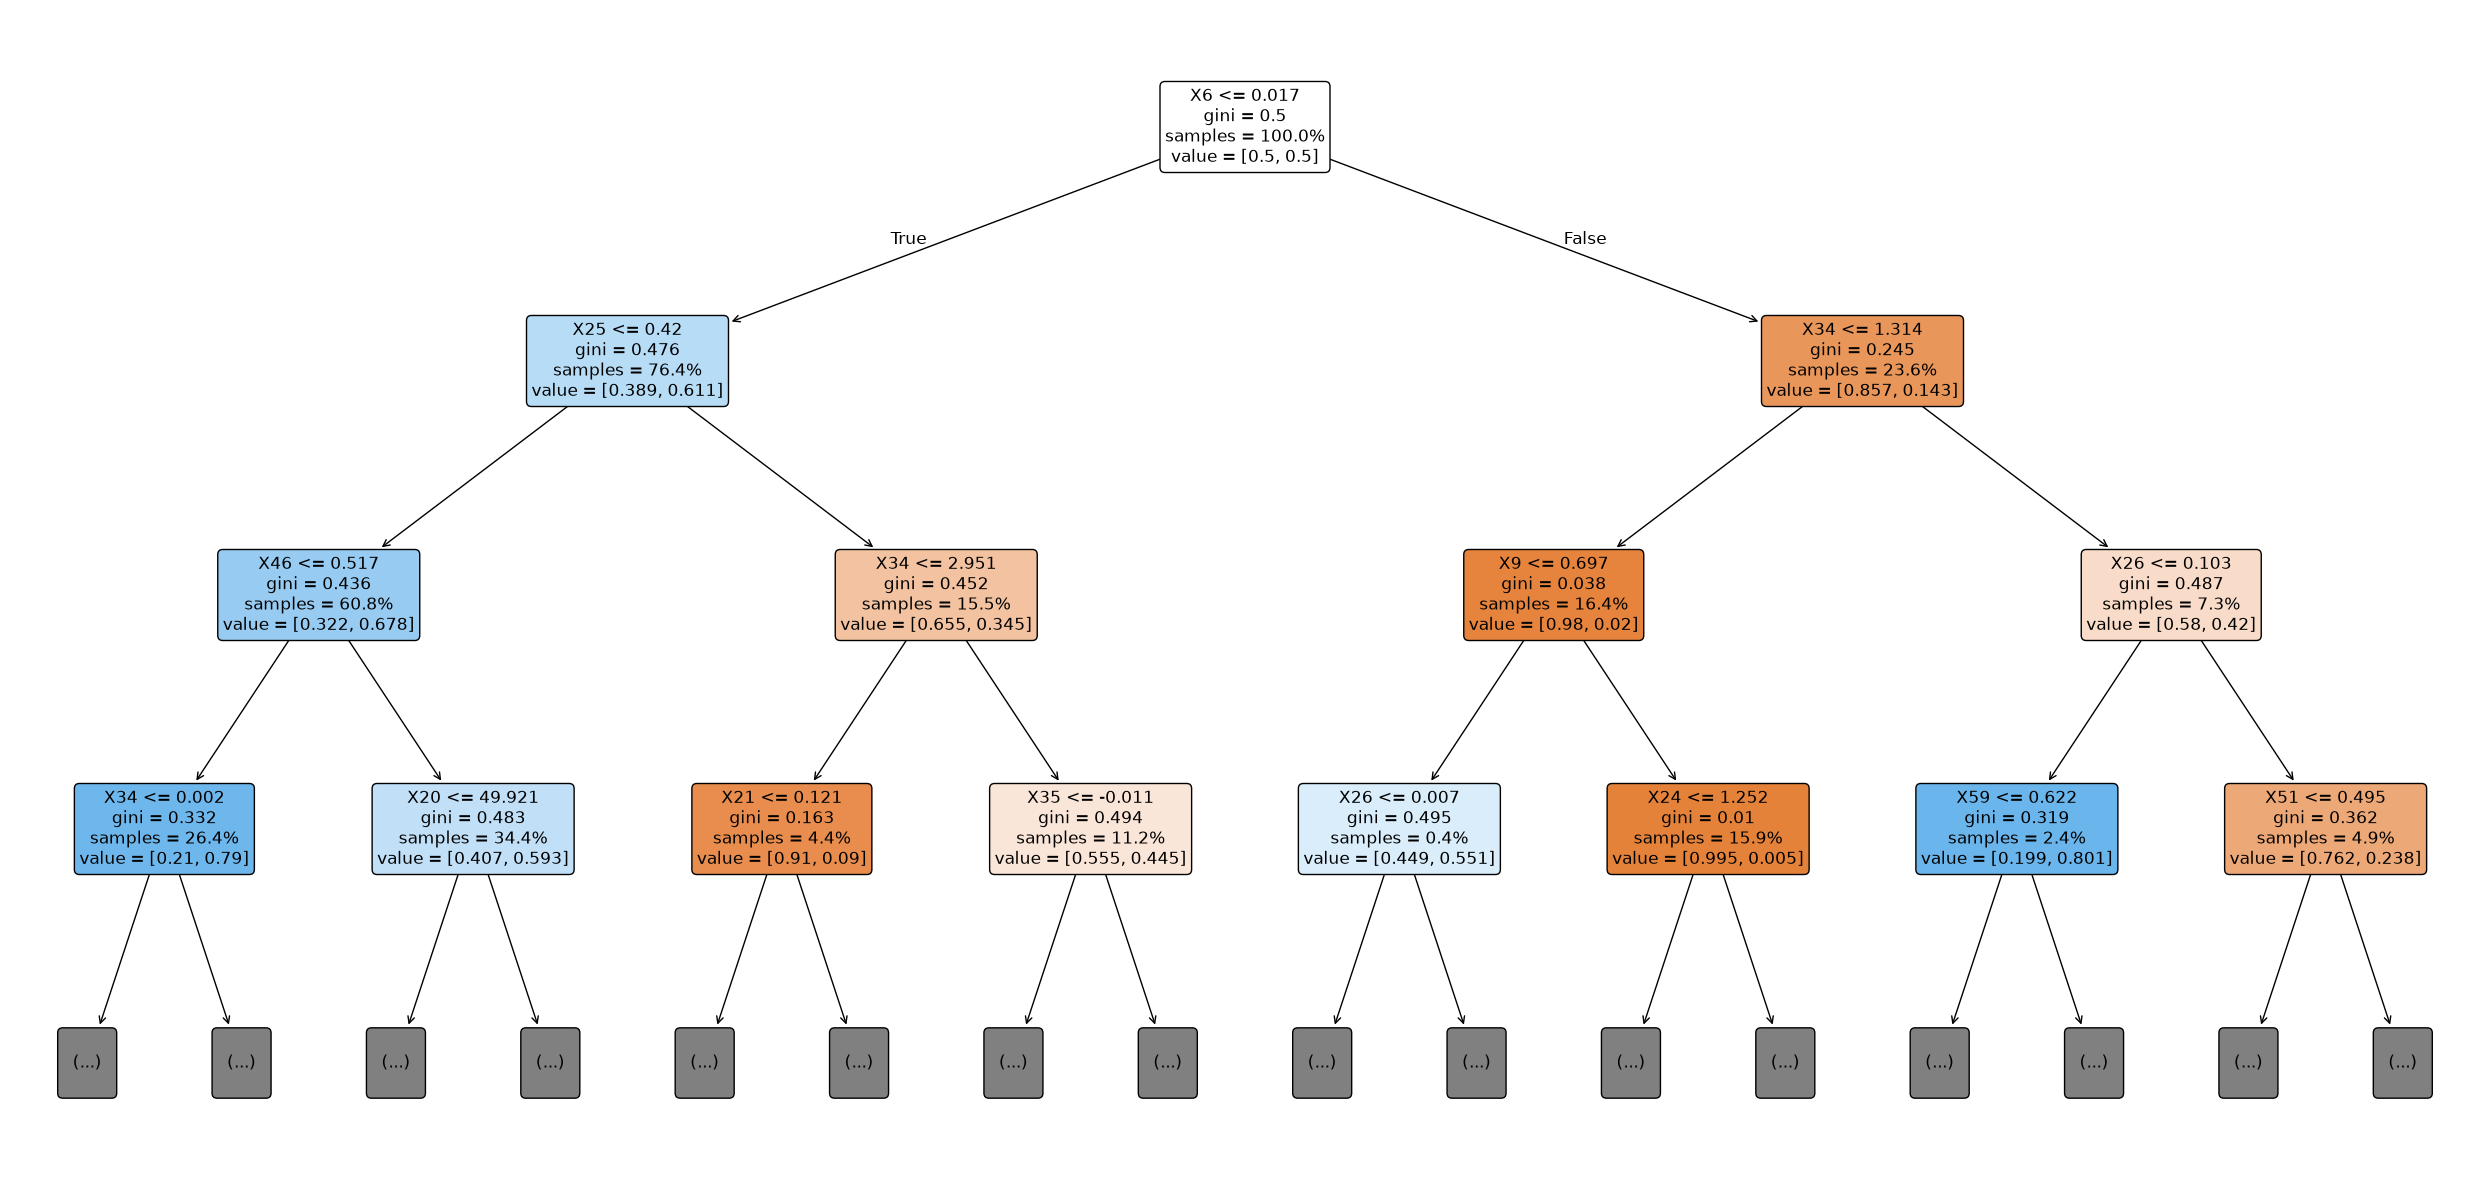

In [109]:
from sklearn.tree import plot_tree
fig,ax = plt.subplots(figsize=(25,12))
plot_tree(
    decision_tree= dtc_model_over.named_steps["decisiontreeclassifier"],
    feature_names=X_train_over.columns.to_list(),
    filled=True,
    rounded =True,
    proportion=True,
    max_depth=3, # maxdepth to show inside the tree plot
    fontsize=12,
    ax=ax
);
plt.tight_layout()
plt.savefig("../reports/figures/single_dt_plot.png", dpi=150)

In [26]:
# Get importances
importances = dtc_model_over.named_steps["decisiontreeclassifier"].feature_importances_

# impportances Series
fea_imp = pd.Series(importances, index=X_train_over.columns)
fea_imp

Year    0.007389
X1      0.000472
X2      0.000744
X3      0.000156
X4      0.031635
          ...   
X60     0.007845
X61     0.024160
X62     0.001300
X63     0.006381
X64     0.009807
Length: 65, dtype: float64

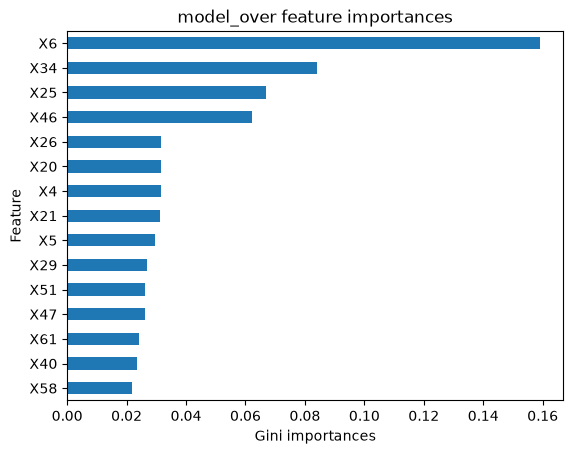

In [27]:
# Plot importances
fea_imp.sort_values().tail(15).plot(kind="barh")
plt.xlabel("Gini importances")
plt.ylabel("Feature")
plt.title("model_over feature importances");

### Gini Feature Importance

Gini feature importance measures the contribution of each feature to reducing impurity across all splits in a **Decision Tree Classifier**. A feature is considered more important if it consistently produces larger reductions in Gini impurity during the tree-building process.

This interpretation differs from **Logistic Regression**, where feature importance is derived from the model coefficients. In logistic regression, each coefficient represents the change in the **log-odds** of the target variable for a one-unit increase in the corresponding feature, and its exponentiated value corresponds to the **odds ratio**. Thus, while Gini importance reflects a feature's role in improving the tree's decision-making process, logistic regression coefficients quantify the strength and direction of the relationship between a feature and the predicted outcome.

Here, it is clear that the **Retained Earnings** feature (**X6**) is the most influential predictor, as it contributes the most to the reduction in Gini impurity across the decision tree. This indicates that **X6** plays the most significant role in improving the tree's ability to separate the classes, making it the most important feature according to the Gini importance metric.


In [28]:
import joblib

# Save the DTC model
joblib.dump(dtc_model_over, "../models/dtc_classifier.joblib")

['../models/dtc_classifier.joblib']

# Bagging models - Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42)
)

rfc_model.fit(X_train_over, y_train_over)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](65,)","['Year','X1','X2',...,'X62','X63','X64']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,65
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fi

In [35]:
from sklearn.model_selection import cross_val_score
# Cross val score
cv_scores = cross_val_score(rfc_model, X_train_over, y_train_over, cv=5, n_jobs=-1)
print(cv_scores)

[0.99891668 0.99950758 0.99871972 0.99852275 0.99832578]


In [38]:
# test accuracy score
print(f"Test accuracy score [Random forest classifier]: {round(cv_scores.mean(),3)}")

Test accuracy score [Random forest classifier]: 0.999


### Random Forest Classifier Performance

The **Random Forest Classifier** achieved a **test accuracy of 0.99 (99%)**, outperforming the **baseline accuracy of 0.98 (98%)**. This indicates that the model performs better than the baseline and is highly effective at classifying the data.

- **Baseline Accuracy:** 0.98 (98%)
- **Test Accuracy:** 0.99 (99%)

In [ ]:
# Extrac max and min depth among the dtc's of the random forest classifier
rfc_depths = [tree.get_depth() for tree in rfc_model.named_steps["randomforestclassifier"].estimators_]
print(f"max depth is: {np.max(rfc_depths)}")
print(f"min depth is: {np.min(rfc_depths)}")


max depth is: 54
min depth is: 28


# Grid Search

In [58]:
from sklearn.model_selection import GridSearchCV

params = {
    "simpleimputer__strategy": ["mean", "median"],
    "randomforestclassifier__n_estimators": range(25,101,25),
    "randomforestclassifier__max_depth": range(10,51,10)
}
params

{'simpleimputer__strategy': ['mean', 'median'],
 'randomforestclassifier__n_estimators': range(25, 101, 25),
 'randomforestclassifier__max_depth': range(10, 51, 10)}

In [59]:
rfc_gs_model = GridSearchCV(
    rfc_model,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1 
)

rfc_gs_model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 51, 10), 'randomforestclassifier__n_estimators': range(25, 101, 25), 'simpleimputer__strategy': ['mean', 'median']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metrice

In [60]:
# Train model
rfc_gs_model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 51, 10), 'randomforestclassifier__n_estimators': range(25, 101, 25), 'simpleimputer__strategy': ['mean', 'median']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metrice

In [ ]:
# Cross validation results of GridSearch
cv_results = pd.DataFrame(rfc_gs_model.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.901361,0.075745,0.043051,0.014179,10,25,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.969864,0.964054,0.959917,0.966220,0.959917,0.963994,0.003812,40
1,3.186939,0.062739,0.041307,0.017071,10,25,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.963857,0.959129,0.968978,0.965038,0.965531,0.964507,0.003183,39
2,5.447241,0.068057,0.046562,0.006764,10,50,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.969076,0.965235,0.963758,0.967993,0.961591,0.965531,0.002734,37
3,5.632828,0.045392,0.038225,0.005470,10,50,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.961985,0.963857,0.965531,0.964940,0.966811,0.964625,0.001628,38
4,8.568468,0.324459,0.091128,0.037289,10,75,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.970652,0.964940,0.966122,0.971046,0.967205,0.967993,0.002443,34


In [66]:
cv_results[cv_results["param_randomforestclassifier__n_estimators"]==25]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.901361,0.075745,0.043051,0.014179,10,25,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.969864,0.964054,0.959917,0.966220,0.959917,0.963994,0.003812,40
1,3.186939,0.062739,0.041307,0.017071,10,25,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.963857,0.959129,0.968978,0.965038,0.965531,0.964507,0.003183,39
8,3.521756,0.188444,0.038101,0.009793,20,25,mean,"{'randomforestclassifier__max_depth': 20, 'ran...",0.998030,0.998818,0.997932,0.998227,0.998227,0.998247,0.000308,31
9,4.193449,0.110802,0.054847,0.014825,20,25,median,"{'randomforestclassifier__max_depth': 20, 'ran...",0.998424,0.999114,0.998129,0.997833,0.997538,0.998208,0.000541,32
16,4.495734,0.837133,0.046973,0.012331,30,25,mean,"{'randomforestclassifier__max_depth': 30, 'ran...",0.998720,0.999311,0.998720,0.998424,0.998227,0.998680,0.000366,23
17,4.217008,0.129564,0.037416,0.005270,30,25,median,"{'randomforestclassifier__max_depth': 30, 'ran...",0.998818,0.999212,0.998818,0.998621,0.997932,0.998680,0.000421,21
24,3.976320,0.116189,0.036207,0.003258,40,25,mean,"{'randomforestclassifier__max_depth': 40, 'ran...",0.999409,0.999311,0.998424,0.998621,0.998424,0.998838,0.000433,7
25,4.294528,0.104767,0.042916,0.009788,40,25,median,"{'randomforestclassifier__max_depth': 40, 'ran...",0.998818,0.999508,0.998818,0.998720,0.998424,0.998858,0.000356,5
32,3.979531,0.152300,0.038968,0.007540,50,25,mean,"{'randomforestclassifier__max_depth': 50, 'ran...",0.999311,0.999311,0.998227,0.998424,0.998424,0.998739,0.000472,16
33,4.368281,0.117517,0.039843,0.006728,50,25,median,"{'randomforestclassifier__max_depth': 50, 'ran...",0.998818,0.999606,0.998818,0.998720,0.998424,0.998877,0.000392,3


In [ ]:
import plotly_express as px

# Plot the max_depth vs mean_fit_time at n_estimators=25
fig = px.line(data_frame=cv_results[cv_results["param_randomforestclassifier__n_estimators"]==50],
        x= "param_randomforestclassifier__max_depth",
        y="mean_fit_time"
        ) 
fig.update_layout(xaxis_title="Max depth", yaxis_title="Training time")
fig.show()
 

In [73]:
# exctracting the best parameters
print(rfc_gs_model.best_params_)

{'randomforestclassifier__max_depth': 40, 'randomforestclassifier__n_estimators': 50, 'simpleimputer__strategy': 'median'}


### Best Hyperparameters from Grid Search

The Grid Search results indicate that the optimal **maximum tree depth (`max_depth`)** is **40**, while the optimal **number of trees (`n_estimators`)** is **50**.

An important observation is that the **Simple Imputer** performed best when using the **median** strategy instead of the **mean**. This is because the dataset contains **skewed features and outliers**, which can significantly influence the mean. In contrast, the median is more robust to extreme values, making it a more appropriate choice for imputing missing data. As a result, using the median helps produce a more reliable preprocessing pipeline and contributes to improved model performance.

In [79]:
# Best Score
print("Best acuracy score is:",round(rfc_gs_model.best_score_,3))


Best acuracy score is: 0.999


In [ ]:
import pickle
# Best Model
rfc_best_model = rfc_gs_model.best_estimator_

# saving the best model using pickle
with open("../models/rfc_best_model.pickle", "wb") as f:
    pickle.dump(rfc_best_model, f)

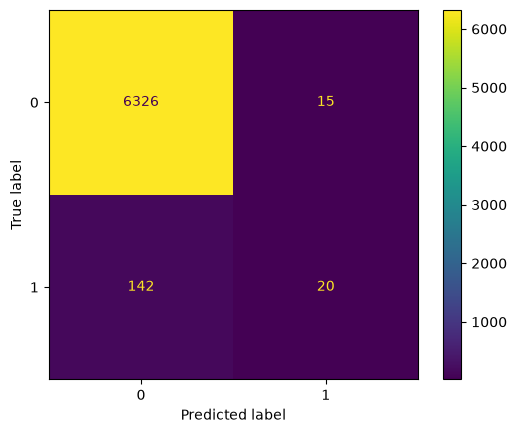

In [83]:
# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rfc_best_model, X_test, y_test)

In [90]:
print(confusion_matrix(y_test, rfc_best_model.predict(X_test)))

[[6326   15]
 [ 142   20]]


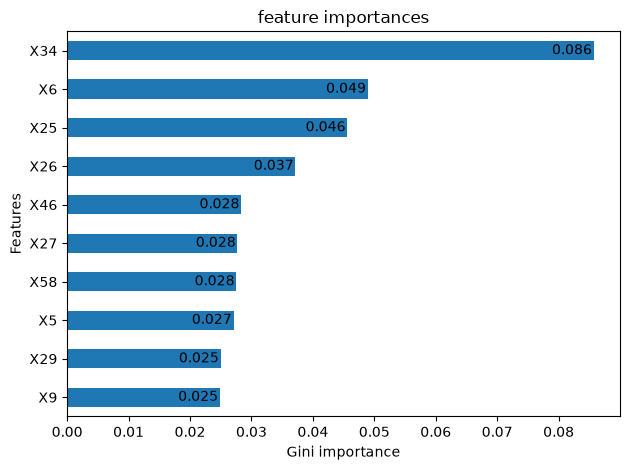

In [107]:
# Feature importances and most 10 important features
features = X_train_over.columns
rfc_importances = rfc_gs_model.best_estimator_.named_steps["randomforestclassifier"].feature_importances_
rfc_fea_imp = pd.Series(rfc_importances, index=features)
rfc_fea_imp.sort_values().tail(10).plot(kind="barh")
plt.xlabel("Gini importance")
plt.ylabel("Features")
plt.title("feature importances")
plt.gca().bar_label(plt.gca().containers[0], fmt="%.3f", padding=-30);
plt.tight_layout()
plt.savefig("../reports/figures/rfc_gini_importances.png", dpi=150)


# XGBoost Model

In [111]:
from xgboost import XGBClassifier

xgb_model = make_pipeline(
    SimpleImputer(),
    XGBClassifier()
)

xgb_model.fit(X_train_over, y_train_over)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](65,)","['Year','X1','X2',...,'X62','X63','X64']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,65
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value`

In [114]:
# xgb_model cross validation score
xgb_cv_score = cross_val_score(xgb_model, X_train_over, y_train_over, cv=5, n_jobs=-1).mean()
print(f"Cross validation score of xgb_model: {round(xgb_cv_score,3)}")

Cross validation score of xgb_model: 0.998


In [148]:
# GridSearc for xgb_mdel
params = {
    "simpleimputer__strategy": ["mean", 'median'],
    "xgbclassifier__max_depth": range(5,26,5),
    "xgbclassifier__n_estimators": range(20,51,5)
}
params

{'simpleimputer__strategy': ['mean', 'median'],
 'xgbclassifier__max_depth': range(5, 26, 5),
 'xgbclassifier__n_estimators': range(20, 51, 5)}

In [149]:
xgb_gs_model = GridSearchCV(
    xgb_model,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [150]:
xgb_gs_model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 70 candidates, totalling 350 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'simpleimputer__strategy': ['mean', 'median'], 'xgbclassifier__max_depth': range(5, 26, 5), 'xgbclassifier__n_estimators': range(20, 51, 5)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`

In [151]:
# cv resutls
results = pd.DataFrame(xgb_gs_model.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_simpleimputer__strategy,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.766030,0.072415,0.024969,0.005350,mean,5,20,"{'simpleimputer__strategy': 'mean', 'xgbclassi...",0.958539,0.955289,0.958440,0.958735,0.956766,0.957554,0.001334,69
1,0.824111,0.033267,0.038737,0.013603,mean,5,25,"{'simpleimputer__strategy': 'mean', 'xgbclassi...",0.973409,0.970553,0.970061,0.970258,0.970061,0.970869,0.001283,67
2,0.864228,0.002974,0.031690,0.010554,mean,5,30,"{'simpleimputer__strategy': 'mean', 'xgbclassi...",0.978038,0.980402,0.977152,0.978925,0.976069,0.978117,0.001484,65
3,0.966702,0.042748,0.030576,0.006790,mean,5,35,"{'simpleimputer__strategy': 'mean', 'xgbclassi...",0.981781,0.986409,0.980993,0.982371,0.981879,0.982687,0.001913,63
4,0.971630,0.032616,0.037466,0.013810,mean,5,40,"{'simpleimputer__strategy': 'mean', 'xgbclassi...",0.985326,0.988970,0.985031,0.986803,0.985621,0.986350,0.001441,61


In [153]:
# xgb_model best parameters
xgb_gs_model.best_params_

{'simpleimputer__strategy': 'median',
 'xgbclassifier__max_depth': 25,
 'xgbclassifier__n_estimators': 50}

In [171]:
# xgb_model best score
xgb_gs_model.best_estimator_

# saving the best xgb model
xgb_best_model = xgb_gs_model.best_estimator_
joblib.dump(xgb_best_model, "../models/xgb_best_model.joblib")

['../models/xgb_best_model.joblib']

In [155]:
# Best score
xgb_gs_model.best_score_

np.float64(0.9987591097104589)

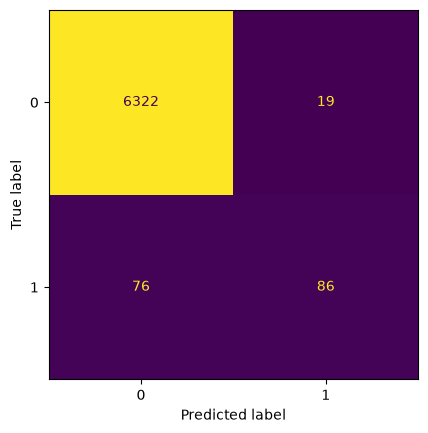

In [159]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, xgb_gs_model.predict(X_test),colorbar=False);


In [163]:
# Evaluating all models on the test set
print(f"Test score of dtc_model: {round(dtc_model_over.score(X_test, y_test),3)}")
print(f"Test score of rfc_model: {round(rfc_best_model.score(X_test, y_test),3)}")
print(f"Test score of xgb_model: {round(xgb_gs_model.score(X_test, y_test),3)}")



Test score of dtc_model: 0.967
Test score of rfc_model: 0.976
Test score of xgb_model: 0.985


From the results above, we observe that only the XGBoost model outperformed the baseline accuracy on the test set. However, this raises an important question: is accuracy the most appropriate evaluation metric when dealing with an imbalanced target variable?

In such scenarios, accuracy alone can be misleading, as it is often dominated by the majority class and may not properly reflect the model’s ability to correctly identify the minority class.

Therefore, from a business perspective, it is more appropriate to evaluate the model using metrics that capture the trade-off between precision and recall, such as F1-score, precision, and recall. These metrics provide a more meaningful evaluation in imbalanced settings and better align with business objectives, where the cost of false positives and false negatives can differ significantly.

# Precision vs Recall
In this problem, the objective is to predict whether a company will go bankrupt or not. The positive class represents bankruptcy, while the negative class represents non-bankrupt companies.

In this context, false negatives are particularly critical, as they occur when a company that is actually at risk of bankruptcy is incorrectly classified as safe. This can lead to significant financial losses and weak risk control.

Therefore, minimizing false negatives is a priority. For this reason, recall is selected as the primary evaluation metric, as it is defined as:

Recall = TP / (TP + FN)

Maximizing recall ensures that the model captures as many at-risk companies as possible, even if this leads to an increase in false positives.

In [164]:
print(classification_report(y_test, dtc_model_over.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6341
           1       0.34      0.35      0.34       162

    accuracy                           0.97      6503
   macro avg       0.66      0.66      0.66      6503
weighted avg       0.97      0.97      0.97      6503



In [165]:
print(classification_report(y_test, rfc_best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6341
           1       0.57      0.12      0.20       162

    accuracy                           0.98      6503
   macro avg       0.77      0.56      0.60      6503
weighted avg       0.97      0.98      0.97      6503



In [166]:
print(classification_report(y_test, xgb_gs_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6341
           1       0.82      0.53      0.64       162

    accuracy                           0.99      6503
   macro avg       0.90      0.76      0.82      6503
weighted avg       0.98      0.99      0.98      6503



In [168]:
# Comparing Models
models = {
    "dtc_model": dtc_model_over.predict(X_test),
    "rfc_model" : rfc_best_model.predict(X_test),
    "xgb_model": xgb_gs_model.predict(X_test)
}

rows =[]

for name,preds in models.items():
    report = classification_report(y_test, preds, output_dict=True)
    rows.append({
        "Model": name,
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "F1 score": report["1"]["f1-score"]
    })
    
df_results = pd.DataFrame(rows)
df_results

,Model,precision,recall,F1 score
0,dtc_model,0.339394,0.345679,0.342508
1,rfc_model,0.571429,0.123457,0.203046
2,xgb_model,0.819048,0.530864,0.644195


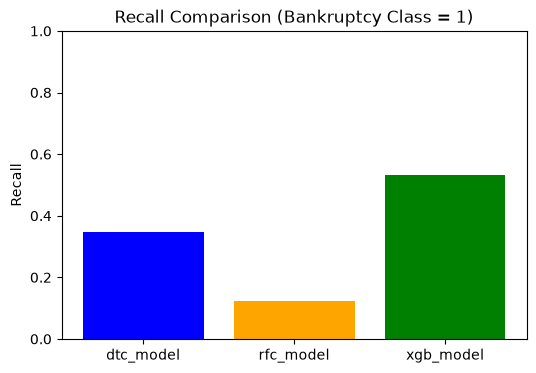

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(df_results["Model"], df_results["recall"], color=["blue", "orange", "green"])
plt.title("Recall Comparison (Bankruptcy Class = 1)")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.show()

The XGBoost model achieved the highest recall for the bankruptcy class (Class 1) compared to the other models evaluated. This indicates that it is the most effective model in identifying companies that are truly at risk of bankruptcy.

In the context of this problem, recall is a critical metric because it measures the model’s ability to correctly detect positive cases, defined as:

Recall = TP / (TP + FN)

A higher recall implies a lower number of false negatives, meaning fewer at-risk companies are incorrectly classified as safe. This is particularly important in bankruptcy prediction, where missing a potentially failing company can lead to significant financial and business consequences.

Therefore, the XGBoost model provides the best balance for this use case by minimizing false negatives and reducing the associated risk.